In [1]:
import pandas as pd
import os
import sys
import json
from pathlib import Path
import numpy as np

# Notebook is in notebooks/, so repo root is parent
REPO_ROOT = Path.cwd().parent
SRC_PATH = REPO_ROOT / "src"

# Insert src at the front of sys.path so imports work
sys.path.insert(0, str(SRC_PATH))

In [2]:
import importlib
import preprocessing.icd_entity_extraction as iee

importlib.reload(iee)

<module 'preprocessing.icd_entity_extraction' from '/Users/brandonng/Documents/GitHub/ClinicalDigitalTwin/src/preprocessing/icd_entity_extraction.py'>

In [3]:
from preprocessing.icd_entity_extraction import load_clinical_data

# Get repo root relative to the current notebook
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Load static preprocessing config
config_path = os.path.join(repo_root, "configs", "icdcode_extractor_params.json")
with open(config_path, "r") as f:
    config = json.load(f)

in_dir = os.path.join(repo_root, config["paths"]["in_dir"])

# Pass in_dir as the first argument
clinical_data = load_clinical_data(in_dir, config)
clinical_data.head(5)

,subject_id,hadm_id,ed_stay_id,ed_intime,ed_outtime,hosp_admittime,hosp_dischtime,race,gender,anchor_age,death_time,icu_stay_id,icu_intime,icu_outtime,icu_count,diagnosis,icd_codes
0,10000032,22595853.0,33258284.0,2180-05-06 19:17:00,2180-05-06 23:30:00,2180-05-06 22:23:00,2180-05-07 17:15:00,WHITE,F,52.0,2180-09-09 00:00:00,NaN,NaN,NaN,NaN,"['Portal hypertension', 'Other ascites', 'Cirr...","['5723', '78959', '5715', '07070', '496', '296..."
1,10000032,22841357.0,38112554.0,2180-06-26 15:54:00,2180-06-26 21:31:00,2180-06-26 18:27:00,2180-06-27 18:49:00,WHITE,F,52.0,2180-09-09 00:00:00,NaN,NaN,NaN,NaN,['Unspecified viral hepatitis C with hepatic c...,"['07071', '78959', '2875', '2761', '496', '571..."
2,10000032,25742920.0,35968195.0,2180-08-05 20:58:00,2180-08-06 01:44:00,2180-08-05 23:44:00,2180-08-07 17:50:00,WHITE,F,52.0,2180-09-09 00:00:00,NaN,NaN,NaN,NaN,['Chronic hepatitis C without mention of hepat...,"['07054', '78959', 'V462', '5715', '2767', '27..."
3,10000032,29079034.0,39399961.0,2180-07-23 05:54:00,2180-07-23 14:00:00,2180-07-23 12:35:00,2180-07-25 17:55:00,WHITE,F,52.0,2180-09-09 00:00:00,[39553978],['2180-07-23 14:00:00'],['2180-07-23 23:50:47'],1.0,"['Other iatrogenic hypotension', 'Chronic hepa...","['45829', '07044', '7994', '2761', '78959', '2..."
4,10000117,27988844.0,33176849.0,2183-09-18 08:41:00,2183-09-18 20:20:00,2183-09-18 18:10:00,2183-09-21 16:30:00,WHITE,F,48.0,NaN,NaN,NaN,NaN,NaN,['Unspecified intracapsular fracture of left f...,"['S72012A', 'W010XXA', 'Y93K1', 'Y92480', 'K21..."


In [4]:
from preprocessing.icd_entity_extraction import clean_icd_codes

clinical_data['icd_codes'] = clinical_data['icd_codes'].apply(clean_icd_codes)
clinical_data.head(5)


,subject_id,hadm_id,ed_stay_id,ed_intime,ed_outtime,hosp_admittime,hosp_dischtime,race,gender,anchor_age,death_time,icu_stay_id,icu_intime,icu_outtime,icu_count,diagnosis,icd_codes
0,10000032,22595853.0,33258284.0,2180-05-06 19:17:00,2180-05-06 23:30:00,2180-05-06 22:23:00,2180-05-07 17:15:00,WHITE,F,52.0,2180-09-09 00:00:00,NaN,NaN,NaN,NaN,"['Portal hypertension', 'Other ascites', 'Cirr...","[572.3, 789.59, 571.5, 070.70, 496, 296.80, 30..."
1,10000032,22841357.0,38112554.0,2180-06-26 15:54:00,2180-06-26 21:31:00,2180-06-26 18:27:00,2180-06-27 18:49:00,WHITE,F,52.0,2180-09-09 00:00:00,NaN,NaN,NaN,NaN,['Unspecified viral hepatitis C with hepatic c...,"[070.71, 789.59, 287.5, 276.1, 496, 571.5, V08..."
2,10000032,25742920.0,35968195.0,2180-08-05 20:58:00,2180-08-06 01:44:00,2180-08-05 23:44:00,2180-08-07 17:50:00,WHITE,F,52.0,2180-09-09 00:00:00,NaN,NaN,NaN,NaN,['Chronic hepatitis C without mention of hepat...,"[070.54, 789.59, V46.2, 571.5, 276.7, 276.1, 4..."
3,10000032,29079034.0,39399961.0,2180-07-23 05:54:00,2180-07-23 14:00:00,2180-07-23 12:35:00,2180-07-25 17:55:00,WHITE,F,52.0,2180-09-09 00:00:00,[39553978],['2180-07-23 14:00:00'],['2180-07-23 23:50:47'],1.0,"['Other iatrogenic hypotension', 'Chronic hepa...","[458.29, 070.44, 799.4, 276.1, 789.59, 276.7, ..."
4,10000117,27988844.0,33176849.0,2183-09-18 08:41:00,2183-09-18 20:20:00,2183-09-18 18:10:00,2183-09-21 16:30:00,WHITE,F,48.0,NaN,NaN,NaN,NaN,NaN,['Unspecified intracapsular fracture of left f...,"[S72.012A, W01.0XXA, Y93.K1, Y92.480, K21.9, E..."


In [5]:
from preprocessing.icd_entity_extraction import map_codes_to_labels

clinical_data['diagnosis_labels'] = clinical_data['icd_codes'].apply(map_codes_to_labels)
clinical_data.head(5)


,subject_id,hadm_id,ed_stay_id,ed_intime,ed_outtime,hosp_admittime,hosp_dischtime,race,gender,anchor_age,death_time,icu_stay_id,icu_intime,icu_outtime,icu_count,diagnosis,icd_codes,diagnosis_labels
0,10000032,22595853.0,33258284.0,2180-05-06 19:17:00,2180-05-06 23:30:00,2180-05-06 22:23:00,2180-05-07 17:15:00,WHITE,F,52.0,2180-09-09 00:00:00,NaN,NaN,NaN,NaN,"['Portal hypertension', 'Other ascites', 'Cirr...","[572.3, 789.59, 571.5, 070.70, 496, 296.80, 30...",[]
1,10000032,22841357.0,38112554.0,2180-06-26 15:54:00,2180-06-26 21:31:00,2180-06-26 18:27:00,2180-06-27 18:49:00,WHITE,F,52.0,2180-09-09 00:00:00,NaN,NaN,NaN,NaN,['Unspecified viral hepatitis C with hepatic c...,"[070.71, 789.59, 287.5, 276.1, 496, 571.5, V08...",[]
2,10000032,25742920.0,35968195.0,2180-08-05 20:58:00,2180-08-06 01:44:00,2180-08-05 23:44:00,2180-08-07 17:50:00,WHITE,F,52.0,2180-09-09 00:00:00,NaN,NaN,NaN,NaN,['Chronic hepatitis C without mention of hepat...,"[070.54, 789.59, V46.2, 571.5, 276.7, 276.1, 4...",[]
3,10000032,29079034.0,39399961.0,2180-07-23 05:54:00,2180-07-23 14:00:00,2180-07-23 12:35:00,2180-07-25 17:55:00,WHITE,F,52.0,2180-09-09 00:00:00,[39553978],['2180-07-23 14:00:00'],['2180-07-23 23:50:47'],1.0,"['Other iatrogenic hypotension', 'Chronic hepa...","[458.29, 070.44, 799.4, 276.1, 789.59, 276.7, ...",[]
4,10000117,27988844.0,33176849.0,2183-09-18 08:41:00,2183-09-18 20:20:00,2183-09-18 18:10:00,2183-09-21 16:30:00,WHITE,F,48.0,NaN,NaN,NaN,NaN,NaN,['Unspecified intracapsular fracture of left f...,"[S72.012A, W01.0XXA, Y93.K1, Y92.480, K21.9, E...",[valvular_endocardial_disease]


In [6]:
from preprocessing.icd_entity_extraction import is_cardiovascular_encounter

clinical_data['is_cardiovascular'] = clinical_data['diagnosis_labels'].apply(is_cardiovascular_encounter)
clinical_data.head(5)

,subject_id,hadm_id,ed_stay_id,ed_intime,ed_outtime,hosp_admittime,hosp_dischtime,race,gender,anchor_age,death_time,icu_stay_id,icu_intime,icu_outtime,icu_count,diagnosis,icd_codes,diagnosis_labels,is_cardiovascular
0,10000032,22595853.0,33258284.0,2180-05-06 19:17:00,2180-05-06 23:30:00,2180-05-06 22:23:00,2180-05-07 17:15:00,WHITE,F,52.0,2180-09-09 00:00:00,NaN,NaN,NaN,NaN,"['Portal hypertension', 'Other ascites', 'Cirr...","[572.3, 789.59, 571.5, 070.70, 496, 296.80, 30...",[],False
1,10000032,22841357.0,38112554.0,2180-06-26 15:54:00,2180-06-26 21:31:00,2180-06-26 18:27:00,2180-06-27 18:49:00,WHITE,F,52.0,2180-09-09 00:00:00,NaN,NaN,NaN,NaN,['Unspecified viral hepatitis C with hepatic c...,"[070.71, 789.59, 287.5, 276.1, 496, 571.5, V08...",[],False
2,10000032,25742920.0,35968195.0,2180-08-05 20:58:00,2180-08-06 01:44:00,2180-08-05 23:44:00,2180-08-07 17:50:00,WHITE,F,52.0,2180-09-09 00:00:00,NaN,NaN,NaN,NaN,['Chronic hepatitis C without mention of hepat...,"[070.54, 789.59, V46.2, 571.5, 276.7, 276.1, 4...",[],False
3,10000032,29079034.0,39399961.0,2180-07-23 05:54:00,2180-07-23 14:00:00,2180-07-23 12:35:00,2180-07-25 17:55:00,WHITE,F,52.0,2180-09-09 00:00:00,[39553978],['2180-07-23 14:00:00'],['2180-07-23 23:50:47'],1.0,"['Other iatrogenic hypotension', 'Chronic hepa...","[458.29, 070.44, 799.4, 276.1, 789.59, 276.7, ...",[],False
4,10000117,27988844.0,33176849.0,2183-09-18 08:41:00,2183-09-18 20:20:00,2183-09-18 18:10:00,2183-09-21 16:30:00,WHITE,F,48.0,NaN,NaN,NaN,NaN,NaN,['Unspecified intracapsular fracture of left f...,"[S72.012A, W01.0XXA, Y93.K1, Y92.480, K21.9, E...",[valvular_endocardial_disease],True


In [7]:
# Flatten labels from lists
all_labels = clinical_data['diagnosis_labels'].explode().dropna().astype(str).str.lower()

label_counts = all_labels.value_counts()
MIN_COUNT = 0  # keep frequent enough labels
label_df = label_counts[label_counts >= MIN_COUNT].reset_index()
label_df.columns = ['diagnosis_labels', 'count']
label_df = label_df.sort_values('count', ascending=True) 
label_df.head(10)
# Label frequency distribution

,diagnosis_labels,count
24,ami_stemi,709
23,unstable_angina_ac_ischemia,1240
22,pericardial_disease_tamponade,1535
21,unspecified_cardiac,1993
20,supraventricular_tachyarrhythmias,2974
19,ventricular_arrhythmias_arrest,3015
18,ami_nstemi,3195
17,stroke_tia,4557
16,pe_dvt_venous_thromboembolism,5243
15,cardiomyopathy_myocarditis,5600


Top 10 labels:
              diagnosis_labels  count
0          hypertension_crisis  99335
1           metabolic_diabetes  92771
2       renal_failure_dialysis  43046
3     chronic_ischemic_disease  34375
4                afib_aflutter  29224
5     obstructive_lung_disease  28832
6           anemia_hematologic  21608
7          heart_failure_acute  14535
8  infectious_pneumonia_sepsis  14511
9        heart_failure_chronic  13550


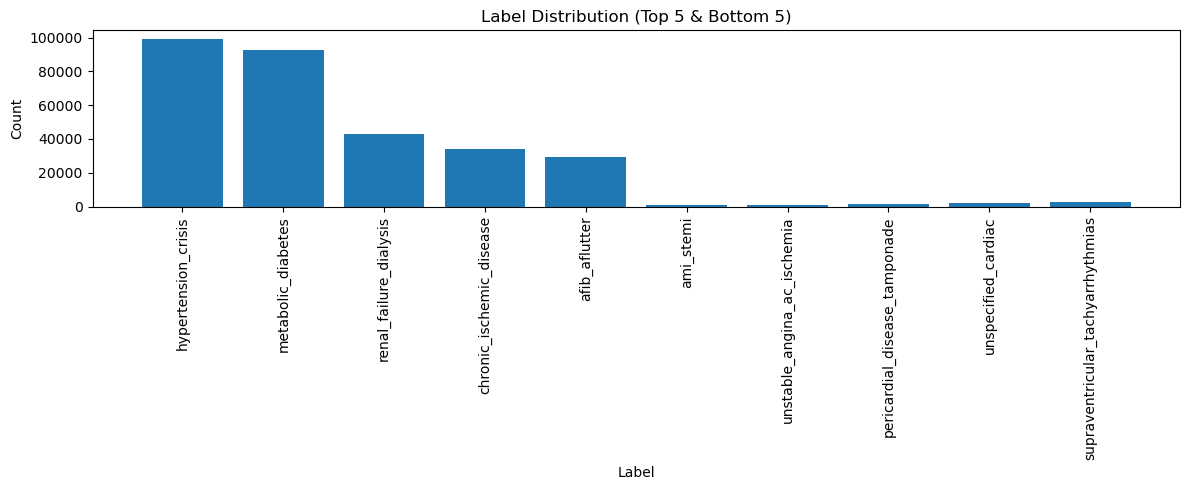

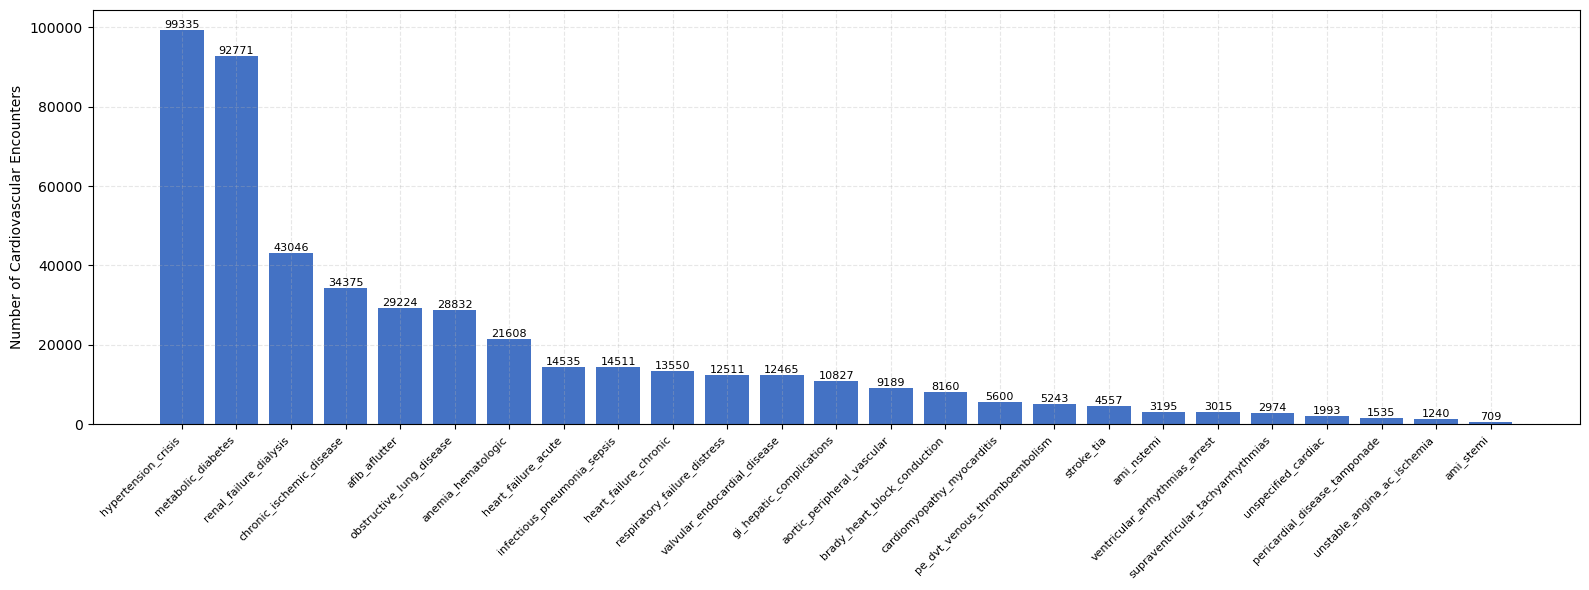

In [12]:
import matplotlib.pyplot as plt

# Flatten labels from lists
all_labels = clinical_data['diagnosis_labels'].explode().dropna().astype(str).str.lower()

label_counts = all_labels.value_counts()
MIN_COUNT = 0  # keep frequent enough labels
label_df = label_counts[label_counts >= MIN_COUNT].reset_index()
label_df.columns = ['diagnosis_labels', 'count']
label_df = label_df.sort_values('count', ascending=False) 

# Display top 10 labels
print("Top 10 labels:")
print(label_df.head(10))

# Get top 5 and bottom 5 labels by count
top_bottom_df = pd.concat([
    label_df.nlargest(5, 'count'),
    label_df.nsmallest(5, 'count')
])

# Plot top 5 and bottom 5
plt.figure(figsize=(12, 5))
plt.bar(top_bottom_df['diagnosis_labels'], top_bottom_df['count'])
plt.xticks(rotation=90)
plt.title("Label Distribution (Top 5 & Bottom 5)")
plt.ylabel("Count")
plt.xlabel("Label")
plt.tight_layout()
plt.show()

# Plot all labels with enhancements
plt.figure(figsize=(16, 6))

bars = plt.bar(label_df['diagnosis_labels'], label_df['count'], color='#4472C4')

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right', fontsize=8)

# Add grid lines
plt.grid(axis='y', linestyle='--', alpha=0.3, zorder=-1)
plt.grid(axis='x', linestyle='--', alpha=0.3, zorder=-1)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', 
             ha='center', va='bottom', fontsize=8)

plt.ylabel("Number of Cardiovascular Encounters")
plt.tight_layout()
plt.show()

In [49]:
clinical_data.columns

Index(['subject_id', 'hadm_id', 'ed_stay_id', 'ed_intime', 'ed_outtime',
       'hosp_admittime', 'hosp_dischtime', 'race', 'gender', 'anchor_age',
       'death_time', 'icu_stay_id', 'icu_intime', 'icu_outtime', 'icu_count',
       'diagnosis', 'icd_codes', 'diagnosis_labels', 'is_cardiovascular'],
      dtype='object')

In [50]:
clinical_data.head()

,subject_id,hadm_id,ed_stay_id,ed_intime,ed_outtime,hosp_admittime,hosp_dischtime,race,gender,anchor_age,death_time,icu_stay_id,icu_intime,icu_outtime,icu_count,diagnosis,icd_codes,diagnosis_labels,is_cardiovascular
0,10000032,22595853.0,33258284.0,2180-05-06 19:17:00,2180-05-06 23:30:00,2180-05-06 22:23:00,2180-05-07 17:15:00,WHITE,F,52.0,2180-09-09 00:00:00,NaN,NaN,NaN,NaN,"['Portal hypertension', 'Other ascites', 'Cirr...","[572.3, 789.59, 571.5, 070.70, 496, 296.80, 30...",[],False
1,10000032,22841357.0,38112554.0,2180-06-26 15:54:00,2180-06-26 21:31:00,2180-06-26 18:27:00,2180-06-27 18:49:00,WHITE,F,52.0,2180-09-09 00:00:00,NaN,NaN,NaN,NaN,['Unspecified viral hepatitis C with hepatic c...,"[070.71, 789.59, 287.5, 276.1, 496, 571.5, V08...",[],False
2,10000032,25742920.0,35968195.0,2180-08-05 20:58:00,2180-08-06 01:44:00,2180-08-05 23:44:00,2180-08-07 17:50:00,WHITE,F,52.0,2180-09-09 00:00:00,NaN,NaN,NaN,NaN,['Chronic hepatitis C without mention of hepat...,"[070.54, 789.59, V46.2, 571.5, 276.7, 276.1, 4...",[],False
3,10000032,29079034.0,39399961.0,2180-07-23 05:54:00,2180-07-23 14:00:00,2180-07-23 12:35:00,2180-07-25 17:55:00,WHITE,F,52.0,2180-09-09 00:00:00,[39553978],['2180-07-23 14:00:00'],['2180-07-23 23:50:47'],1.0,"['Other iatrogenic hypotension', 'Chronic hepa...","[458.29, 070.44, 799.4, 276.1, 789.59, 276.7, ...",[],False
4,10000117,27988844.0,33176849.0,2183-09-18 08:41:00,2183-09-18 20:20:00,2183-09-18 18:10:00,2183-09-21 16:30:00,WHITE,F,48.0,NaN,NaN,NaN,NaN,NaN,['Unspecified intracapsular fracture of left f...,"[S72.012A, W01.0XXA, Y93.K1, Y92.480, K21.9, E...",[valvular_endocardial_disease],True


In [51]:
clinical_data['is_cardiovascular'].value_counts()


is_cardiovascular
False    377264
True     116967
Name: count, dtype: int64

/var/folders/bn/28hly9dd0z36556zl0gx44v80000gn/T/ipykernel_90890/3129167776.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cardio_counts = [cardio_ed[1], cardio_hosp[1]]  # is_cardiovascular = 1
/var/folders/bn/28hly9dd0z36556zl0gx44v80000gn/T/ipykernel_90890/3129167776.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  non_cardio_counts = [cardio_ed[0], cardio_hosp[0]]  # is_cardiovascular = 0


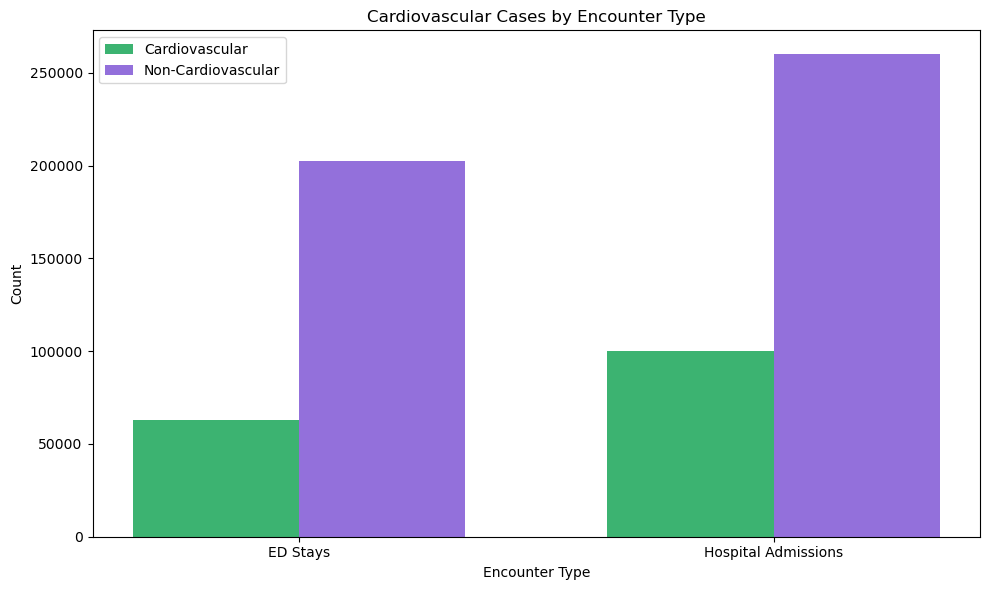

ED - Cardiovascular: 63,065, Non-Cardiovascular: 202,637
Hospital - Cardiovascular: 100,354, Non-Cardiovascular: 259,914


/var/folders/bn/28hly9dd0z36556zl0gx44v80000gn/T/ipykernel_90890/3129167776.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"ED - Cardiovascular: {cardio_ed[1]:,}, Non-Cardiovascular: {cardio_ed[0]:,}")
/var/folders/bn/28hly9dd0z36556zl0gx44v80000gn/T/ipykernel_90890/3129167776.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Hospital - Cardiovascular: {cardio_hosp[1]:,}, Non-Cardiovascular: {cardio_hosp[0]:,}")


In [52]:
import matplotlib.pyplot as plt

# Count cardiovascular cases by encounter type
cardio_ed = clinical_data[clinical_data['ed_stay_id'].notna()]['is_cardiovascular'].value_counts()
cardio_hosp = clinical_data[clinical_data['hadm_id'].notna()]['is_cardiovascular'].value_counts()

# Prepare data for plotting
categories = ['ED Stays', 'Hospital Admissions']
cardio_counts = [cardio_ed[1], cardio_hosp[1]]  # is_cardiovascular = 1
non_cardio_counts = [cardio_ed[0], cardio_hosp[0]]  # is_cardiovascular = 0

# Create grouped bar chart
x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, cardio_counts, width, label='Cardiovascular', color='mediumseagreen')
plt.bar(x + width/2, non_cardio_counts, width, label='Non-Cardiovascular', color='mediumpurple')

plt.xlabel('Encounter Type')
plt.ylabel('Count')
plt.title('Cardiovascular Cases by Encounter Type')
plt.xticks(x, categories)
plt.legend()
plt.tight_layout()
plt.show()

# Print the counts
print(f"ED - Cardiovascular: {cardio_ed[1]:,}, Non-Cardiovascular: {cardio_ed[0]:,}")
print(f"Hospital - Cardiovascular: {cardio_hosp[1]:,}, Non-Cardiovascular: {cardio_hosp[0]:,}")